# Measure your closing-line value

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Propertyscout001/puntersedge-datasets/blob/main/notebooks/02_measure_your_closing_line_value.ipynb)

**Closing-line value (CLV)** compares the price you took with the fair price at the jump:

$$\text{CLV} = \frac{\text{price taken}}{\text{fair closing price}} - 1$$

If the closing market is accurate, the expected return of a bet is exactly its CLV: back a runner at $6.00 whose fair closing price is $5.00 and you expect to make 20% on that bet, win or lose. That makes CLV the fastest honest scorecard for a betting method. Profit takes thousands of bets to separate skill from luck; CLV gets there in a fraction of that.

This notebook checks that claim on a month of real Australian racing, then shows how to score your own bets. It uses the free [closing-line dataset](https://puntersedge.online/datasets) and runs in Colab with nothing to install.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RELEASE = "2026-09"
URL = ("https://puntersedge.online/datasets/au-racing-closing-lines/"
       f"{RELEASE}/au-racing-closing-lines-{RELEASE}.parquet")

# Reads the release straight from puntersedge.online (about 3 MB).
# Set PUNTERSEDGE_DATASET_FILE to the path of a downloaded copy to read that instead.
df = pd.read_parquet(os.environ.get("PUNTERSEDGE_DATASET_FILE", URL))

NAMES = {"tab": "TAB", "ladbrokes_au": "Ladbrokes", "pointsbetau": "PointsBet",
         "betright": "BetRight", "tabtouch": "TABtouch"}
print(f"{len(df):,} rows, {df.race_id.nunique():,} races, "
      f"{df.meeting_date_aet.min()} to {df.meeting_date_aet.max()}")
print("Bookmakers:", ", ".join(NAMES.get(b, b) for b in sorted(df.bookmaker_key.unique())))

233,872 rows, 6,274 races, 2026-09-01 to 2026-09-30
Bookmakers: BetRight, Ladbrokes, PointsBet, TAB, TABtouch


In [2]:
GREEN, AMBER, GREY, INK = "#1B7A4B", "#E3A008", "#8A948C", "#131C16"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#B8C1B6",
    "axes.grid": True, "grid.color": "#E6EAE3", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": "#5C6961", "ytick.color": "#5C6961",
    "text.parse_math": False,                 # "$3.00 to $6.99" is a price range, not maths
})

## The fair closing price

Each row carries `consensus_close_price`: the market's margin-free price for the runner at the close. Each bookmaker's margin is removed with the power method, the median probability across bookmakers is taken, and the field is renormalised to 100%. It is the same for every bookmaker's row of that runner.

We keep races with a final result and one winner.

In [3]:
# One row per runner, for races with a final result and exactly one winner.
# Harness results name the placegetters only, so an empty finish_position in a resulted
# race means the runner did not win.
winners = df[df.finish_position.eq(1)].groupby("race_id").runner_key.nunique()
resulted = df[df.result_status.eq("final")].race_id.unique()
single = winners[winners.eq(1)].index.intersection(resulted)

runners = (df[df.race_id.isin(single)]
           .groupby(["race_id", "runner_key"])
           .agg(category=("category", "first"),
                best_open=("open_win_price", "max"),
                best_close=("close_win_price", "max"),
                fair_open=("consensus_open_price", "first"),
                fair_close=("consensus_close_price", "first"),
                from_baseline=("open_is_baseline", "all"),
                won=("finish_position", lambda s: bool((s == 1).any())))
           .reset_index())
print(f"{runners.race_id.nunique():,} races with one winner, {len(runners):,} runners")

6,169 races with one winner, 48,947 runners


## Does CLV predict profit?

To test it we need a lot of bets with a wide spread of CLV. Take every runner at its **best opening price** across the five bookmakers, 60 minutes before the jump, and score it against the fair closing price. This is not a betting method; it is a large, varied sample.

If the fair closing price is accurate, the average return in each CLV bucket should sit on the dashed line, where return equals CLV.

In [4]:
bets = runners[runners.from_baseline & runners.fair_close.notna() & runners.best_open.gt(1)].copy()
bets["clv"] = bets.best_open / bets.fair_close - 1
bets["profit"] = np.where(bets.won, bets.best_open - 1, -1.0)       # $1 win bets

edges = [-1, -0.3, -0.2, -0.1, 0, 0.1, 0.2, 0.4, np.inf]
bets["bucket"] = pd.cut(bets.clv, edges)
by = bets.groupby("bucket", observed=True).agg(bets=("profit", "size"), mean_clv=("clv", "mean"),
                                               roi=("profit", "mean"), sd=("profit", "std"))
by["roi_se"] = by.sd / np.sqrt(by.bets)
by[["mean_clv", "roi", "roi_se"]] = by[["mean_clv", "roi", "roi_se"]] * 100
by.drop(columns="sd").round(1)

,bets,mean_clv,roi,roi_se
bucket,,,,
"(-1.0, -0.3]",21023,-49.9,-49.9,2.4
"(-0.3, -0.2]",6966,-25.0,-21.6,4.9
"(-0.2, -0.1]",6419,-15.1,-19.3,3.3
"(-0.1, 0.0]",4631,-5.3,2.1,6.1
"(0.0, 0.1]",2601,4.3,1.2,5.6
"(0.1, 0.2]",1195,14.3,-3.4,9.8
"(0.2, 0.4]",906,28.1,45.7,26.2
"(0.4, inf]",667,78.7,55.8,36.6


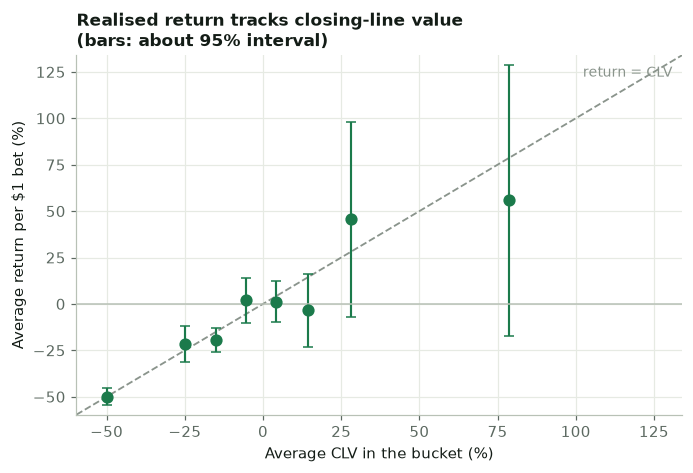

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
lim = [min(by.mean_clv.min(), (by.roi - 2 * by.roi_se).min()) - 5, max(by.mean_clv.max(), (by.roi + 2 * by.roi_se).max()) + 5]
ax.plot(lim, lim, ls="--", lw=1.2, color=GREY)
ax.annotate("return = CLV", (lim[1], lim[1]), xytext=(-6, -14), textcoords="offset points", ha="right", color=GREY, fontsize=9)
ax.errorbar(by.mean_clv, by.roi, yerr=2 * by.roi_se, fmt="o", ms=7, color=GREEN, ecolor=GREEN, elinewidth=1.4, capsize=3)
ax.axhline(0, color="#B8C1B6", lw=1)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Average CLV in the bucket (%)")
ax.set_ylabel("Average return per $1 bet (%)")
ax.set_title("Realised return tracks closing-line value\n(bars: about 95% interval)", loc="left")
fig.tight_layout()
plt.show()

Every bucket's interval reaches the dashed line: on average, the return was the CLV. The intervals on the right are wide because long-priced winners are rare, which is the next point.

## Why CLV is the better scorecard

A $1 win bet returns either −$1 or a large win, so profit is noisy. CLV is known the moment the race jumps and varies far less from bet to bet. Here is how precisely each one estimates your edge after a given number of bets.

In [6]:
sd_profit = bets.profit.std()
sd_clv = bets.clv.std()
for n in (100, 500, 2000):
    print(f"after {n:>5,} bets: profit is accurate to about ±{2 * sd_profit / np.sqrt(n) * 100:4.1f}%, "
          f"CLV to about ±{2 * sd_clv / np.sqrt(n) * 100:4.1f}%")
print(f"\nProfit needs about {(sd_profit / sd_clv) ** 2:.0f}x as many bets as CLV to reach the same precision.")

after   100 bets: profit is accurate to about ±76.0%, CLV to about ± 5.6%
after   500 bets: profit is accurate to about ±34.0%, CLV to about ± 2.5%
after 2,000 bets: profit is accurate to about ±17.0%, CLV to about ± 1.3%

Profit needs about 182x as many bets as CLV to reach the same precision.


## Score your own bets

Put your bets in a CSV with the columns `venue`, `meeting_date_aet` (YYYY-MM-DD), `race_number`, `runner_name` and `price` (the decimal odds you took), then read it in place of the example below. The example uses three real runners from the release with made-up prices.

In [7]:
import re


def fold(name):
    """The dataset's runner_key: lowercase letters and digits, country suffix dropped."""
    return re.sub(r"[^a-z0-9]", "", re.sub(r"\s*\([^)]*\)\s*$", "", str(name)).lower())


fair = (df.groupby(["venue", "meeting_date_aet", "race_number", "runner_key"])
          .agg(fair_close=("consensus_close_price", "first"), best_close=("close_win_price", "max"),
               finish_position=("finish_position", "min"))
          .reset_index())
fair["meeting_date_aet"] = fair.meeting_date_aet.astype(str)


def score(bets):
    b = bets.assign(runner_key=bets.runner_name.map(fold), venue_l=bets.venue.str.lower(),
                    meeting_date_aet=bets.meeting_date_aet.astype(str))
    out = b.merge(fair.assign(venue_l=fair.venue.str.lower()).drop(columns="venue"),
                  on=["venue_l", "meeting_date_aet", "race_number", "runner_key"], how="left")
    out["clv_%"] = (out.price / out.fair_close - 1) * 100
    out["vs_best_close_%"] = (out.price / out.best_close - 1) * 100
    return out[["venue", "meeting_date_aet", "race_number", "runner_name", "price", "fair_close",
                "best_close", "clv_%", "vs_best_close_%", "finish_position"]].round(2)


# Example: three runners from the release, with made-up prices taken.
sample = df[df.consensus_close_price.notna()].drop_duplicates("runner_key").sample(3, random_state=7)
my_bets = pd.DataFrame({
    "venue": sample.venue.values, "meeting_date_aet": sample.meeting_date_aet.astype(str).values,
    "race_number": sample.race_number.values, "runner_name": sample.runner_name.values,
    "price": (sample.consensus_close_price * [1.15, 0.95, 1.05]).round(2).values,
})
# my_bets = pd.read_csv("my_bets.csv")
scored = score(my_bets)
scored

,venue,meeting_date_aet,race_number,runner_name,price,fair_close,best_close,clv_%,vs_best_close_%,finish_position
0,NOWRA,2026-09-09,8,Hayden's Fancy,11.26,9.79,7.5,14.99,50.13,NaN
1,GRAFTON,2026-09-07,8,Splashed,12.08,12.71,10.0,-4.96,20.80,2.0
2,Sunshine Coast,2026-09-06,5,Miss Dynamo,29.65,28.24,26.0,4.99,14.04,5.0


In [8]:
matched = scored.fair_close.notna()
print(f"{matched.sum()} of {len(scored)} bets matched a fair closing price; "
      f"average CLV {scored.loc[matched, 'clv_%'].mean():+.1f}%")

3 of 3 bets matched a fair closing price; average CLV +5.0%


A positive average CLV over a few hundred bets is far stronger evidence of an edge than a profit over the same bets. Bets the dataset can't match are usually a venue spelled differently or a race outside the release's month and bookmakers.

Next: [Does late money win?](03_does_late_money_win.ipynb) · Previous: [Which bookmaker is sharpest?](01_which_bookmaker_is_sharpest.ipynb)

---
Data: [PuntersEdge Australian racing closing-line sample](https://puntersedge.online/datasets), CC BY 4.0.
Credit "PuntersEdge Australian racing closing-line sample (puntersedge.online)". Code in this notebook: MIT.
The full archive, every served bookmaker and New Zealand racing are in the [PuntersEdge API](https://puntersedge.online/api).

For research and analysis, not betting advice. 18+. Gambling Help Online: 1800 858 858.